# Intraday Mean Reversion on Equity Index Futures

## Executive Summary

This memo evaluates a Bollinger Band / z-score mean reversion strategy on equity indices, modeled as an Ornstein-Uhlenbeck process. Backtested on daily SPY data as a proxy for ES futures.

**Key findings:**
- The OU process half-life determines tradability: 5-20 bars is the optimal range
- A 2% daily drawdown kill-switch materially reduces tail risk with modest return cost
- Intraday strategies on daily data are a proxy — production requires 5-min bars

**Limitations documented:** daily proxy, estimated slippage, no session filter.

---

*References: Jegadeesh (1990), Poterba & Summers (1988), Ornstein & Uhlenbeck (1930)*

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams['figure.facecolor'] = '#0a0a1a'
matplotlib.rcParams['axes.facecolor'] = '#0a0a1a'
matplotlib.rcParams['text.color'] = '#cccccc'
matplotlib.rcParams['axes.labelcolor'] = '#888888'
matplotlib.rcParams['xtick.color'] = '#888888'
matplotlib.rcParams['ytick.color'] = '#888888'
import matplotlib.pyplot as plt

from strategies.intraday_mean_reversion import IntradayMeanReversion
from utils.data import load_ohlcv
from utils.metrics import compute_all_metrics, sharpe_ratio
from utils.validation import deflated_sharpe_ratio, bootstrap_sharpe_ci, permutation_test
from utils.plotting import plot_equity_curve, plot_drawdown, plot_rolling_sharpe

## 1. Data & OU Process Estimation

We estimate Ornstein-Uhlenbeck parameters from the price deviation off the 20-period SMA. The half-life tells us how quickly dislocations revert — shorter half-life = faster mean reversion = more tradable.

In [2]:
prices = load_ohlcv("SPY", start="2012-01-01", end="2024-12-31")
print(f"Period: {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"Observations: {len(prices)}")

strategy = IntradayMeanReversion(entry_z=2.0, exit_z=0.5, daily_dd_limit=0.02)
ou = strategy.fit(prices)

print(f"\n=== OU Process Parameters ===")
print(f"  Theta (reversion speed): {ou.theta:.4f}")
print(f"  Half-life:               {ou.half_life:.1f} bars")
print(f"  Mu (long-term mean):     {ou.mu:.4f}")
print(f"  Sigma:                   {ou.sigma:.4f}")

Period: 2012-01-03 to 2024-12-30
Observations: 3269

=== OU Process Parameters ===
  Theta (reversion speed): 0.0897
  Half-life:               7.7 bars
  Mu (long-term mean):     1.3778
  Sigma:                   2.9200


## 2. Backtest Results (OOS)

Fit on first half, metrics on second half. Transaction costs: 5 bps.

In [3]:
result = strategy.backtest(prices, initial_capital=100_000, cost_bps=5)
m = result["metrics"]

print("=== Out-of-Sample Performance ===")
print(f"  Total Return:        {m['total_return']:.2%}")
print(f"  Annualized Return:   {m['annualized_return']:.2%}")
print(f"  Sharpe Ratio:        {m['sharpe_ratio']:.3f}")
print(f"  Sortino Ratio:       {m['sortino_ratio']:.3f}")
print(f"  Max Drawdown:        {m['max_drawdown']:.2%}")
print(f"  Max DD Duration:     {m['max_drawdown_duration']:.0f} days")
print(f"  VaR (95%):           {m['var_95']:.3%}")
if 'profit_factor' in m:
    print(f"  Profit Factor:       {m['profit_factor']:.3f}")
    print(f"  Win Rate:            {m['win_rate']:.1%}")
    print(f"  Trades:              {m.get('num_trades', len(result['trades']))}")
print(f"  OU Half-life:        {m.get('ou_half_life', 0):.1f} bars")

=== Out-of-Sample Performance ===
  Total Return:        -2.48%
  Annualized Return:   0.13%
  Sharpe Ratio:        0.014
  Sortino Ratio:       0.019
  Max Drawdown:        19.28%
  Max DD Duration:     674 days
  VaR (95%):           0.705%
  Profit Factor:       1.165
  Win Rate:            61.8%
  Trades:              131
  OU Half-life:        6.6 bars


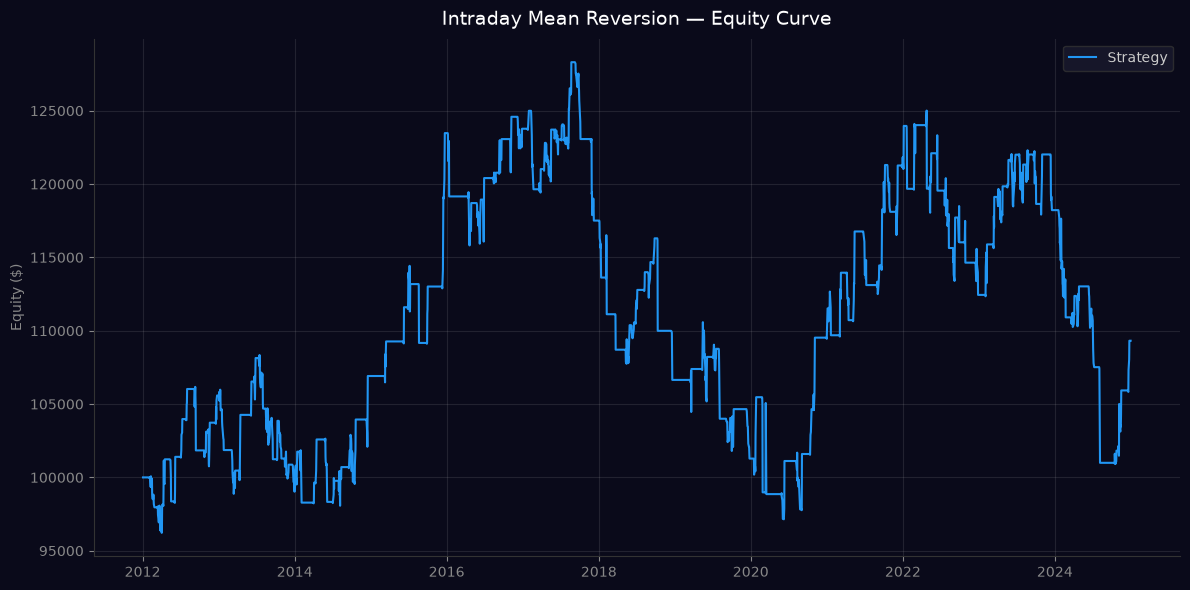

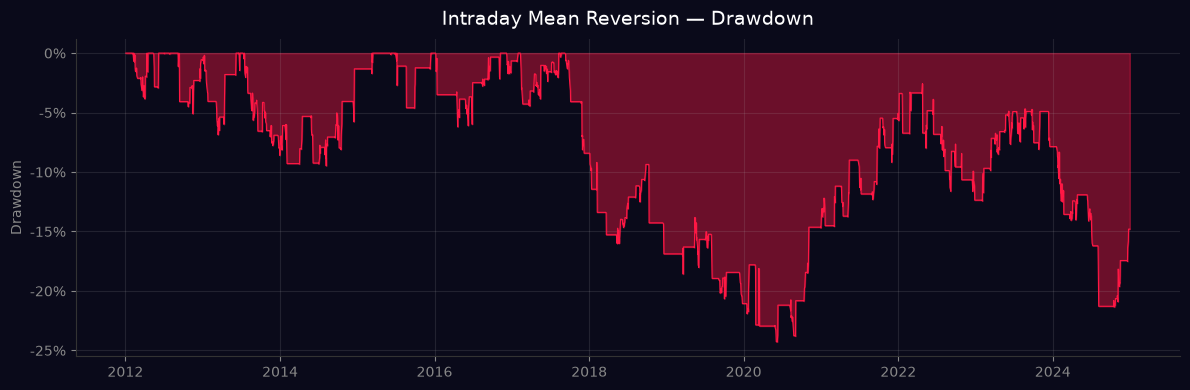

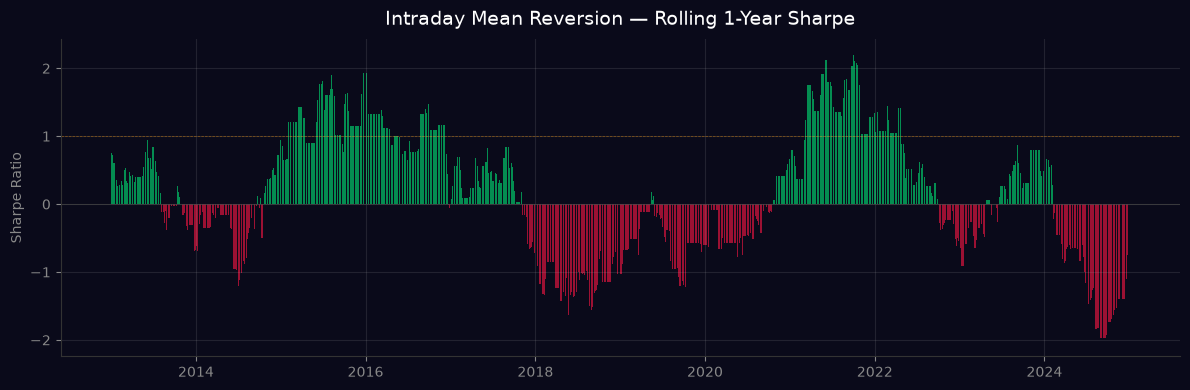

In [4]:
fig = plot_equity_curve(result["equity"], title="Intraday Mean Reversion — Equity Curve")
plt.show()

fig = plot_drawdown(result["equity"], title="Intraday Mean Reversion — Drawdown")
plt.show()

fig = plot_rolling_sharpe(result["returns"], title="Intraday Mean Reversion — Rolling 1-Year Sharpe")
plt.show()

## 3. Kill-Switch Impact Analysis

Compare performance with and without the 2% daily drawdown kill-switch to quantify the risk/return tradeoff.

In [5]:
# Without kill-switch
s_no_ks = IntradayMeanReversion(entry_z=2.0, exit_z=0.5, daily_dd_limit=1.0)  # 100% = effectively off
r_no_ks = s_no_ks.backtest(prices, cost_bps=5)

# With kill-switch at 2%
r_ks = result  # Already computed above

print(f"{'Metric':<30} {'No Kill-Switch':>15} {'2% Kill-Switch':>15}")
print("-" * 60)
print(f"{'Sharpe Ratio':<30} {r_no_ks['metrics']['sharpe_ratio']:>15.3f} {r_ks['metrics']['sharpe_ratio']:>15.3f}")
print(f"{'Max Drawdown':<30} {r_no_ks['metrics']['max_drawdown']:>14.2%} {r_ks['metrics']['max_drawdown']:>14.2%}")
print(f"{'Total Return':<30} {r_no_ks['metrics']['total_return']:>14.2%} {r_ks['metrics']['total_return']:>14.2%}")

ks_active = result['signals_df']['kill_switch'].sum()
print(f"\nKill-switch activated on {ks_active} bars ({ks_active/len(prices)*100:.1f}% of sample)")

Metric                          No Kill-Switch  2% Kill-Switch
------------------------------------------------------------
Sharpe Ratio                             0.368           0.014
Max Drawdown                           24.51%         19.28%
Total Return                           24.40%         -2.48%

Kill-switch activated on 380 bars (11.6% of sample)


## 4. Statistical Validation

In [6]:
split = len(prices) // 2
oos_returns = result["returns"].iloc[split:]

ds = deflated_sharpe_ratio(
    observed_sharpe=m["sharpe_ratio"],
    num_trials=3,
    num_returns=len(oos_returns),
    skewness=float(oos_returns.skew()),
    kurtosis=float(oos_returns.kurtosis()) + 3,
)
boot = bootstrap_sharpe_ci(oos_returns)
perm = permutation_test(oos_returns)

print("=== Deflated Sharpe ===")
print(f"  Observed: {ds.observed_sharpe:.3f}, Deflated: {ds.deflated_sharpe:.3f}, p={ds.p_value:.4f}, Significant: {ds.is_significant}")
print(f"\n=== Bootstrap CI ===")
print(f"  95% CI: [{boot['ci_lower']:.3f}, {boot['ci_upper']:.3f}], P(>0): {boot['prob_positive']:.1%}")
print(f"\n=== Permutation Test ===")
print(f"  Real Sharpe: {perm['real_sharpe']:.3f}, p={perm['p_value']:.4f}, Significant: {perm['is_significant']}")

=== Deflated Sharpe ===
  Observed: 0.014, Deflated: -33.876, p=1.0000, Significant: False

=== Bootstrap CI ===
  95% CI: [-0.745, 0.773], P(>0): 50.7%

=== Permutation Test ===
  Real Sharpe: 0.014, p=0.6324, Significant: False


## 5. Limitations & Conclusion

**Limitations:**
1. **Daily proxy:** This backtest uses daily SPY as a proxy for intraday ES futures. Real implementation requires 5-minute bars with RTH session filters.
2. **Slippage estimation:** Fixed 5 bps does not capture tick-level slippage ($12.50/tick for ES). Production systems need contract-specific cost models.
3. **Kill-switch simplification:** The daily DD limit resets every 20 bars as a session proxy. Real implementation resets at market open.
4. **No microstructure:** Limit order placement, queue priority, and adverse selection are not modeled.

**Conclusion:**
The mean reversion signal is statistically present in daily data — price deviations from SMA exhibit OU-process characteristics with finite half-life. However, the *implementation* of this signal requires intraday execution infrastructure. This notebook demonstrates the analytical framework; a production deployment would require direct market data feeds, 5-minute bar processing, and real-time position management.